In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## 1. Загрузка данных

Укажите папку, куда `generate_dataset.py` сохранил `.npy` файлы.

In [ ]:
data_dir = Path("./data")

x0 = np.load(data_dir / "p0_samples.npy")
x1 = np.load(data_dir / "p1_samples.npy")

# Парная выборка (истинное EOT/SB-сопряжение) — опционально, если генерировали с --paired
paired_path0 = data_dir / "p0_paired.npy"
paired_path1 = data_dir / "p1_paired.npy"
has_paired = paired_path0.exists() and paired_path1.exists()

if has_paired:
    x0_paired = np.load(paired_path0)
    x1_paired = np.load(paired_path1)

print(f"x0: shape={x0.shape}, dtype={x0.dtype}, min={x0.min()}, max={x0.max()}")
print(f"x1: shape={x1.shape}, dtype={x1.dtype}, min={x1.min()}, max={x1.max()}")
print(f"Парная выборка найдена: {has_paired}")

## 2. Определяем параметры бенчмарка (D, S) по данным

In [ ]:
D = x0.shape[1]
# число дискретных состояний по каждой координате (предполагаем одинаковое S для всех d)
S = int(max(x0.max(), x1.max()) + 1)

print(f"D (размерность) = {D}")
print(f"S (число состояний на координату) = {S}")

## 3. 2D-хитмапы p_0 и p_1 (для D=2)

Если D=2, каждую выборку удобно представить как 2D-гистограмму по дискретной решётке [0, S-1] x [0, S-1].

In [ ]:
if D == 2:
    bins = np.arange(S + 1) - 0.5  # границы бинов так, чтобы каждое целое значение попадало в свой бин

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

    h0, _, _, im0 = axes[0].hist2d(x0[:, 0], x0[:, 1], bins=[bins, bins], cmap="viridis")
    axes[0].set_title(f"$p_0$ (N={len(x0)})")
    axes[0].set_xlabel("$x^{(1)}$")
    axes[0].set_ylabel("$x^{(2)}$")
    fig.colorbar(im0, ax=axes[0], label="count")

    h1, _, _, im1 = axes[1].hist2d(x1[:, 0], x1[:, 1], bins=[bins, bins], cmap="magma")
    axes[1].set_title(f"$p_1$ (N={len(x1)})")
    axes[1].set_xlabel("$x^{(1)}$")
    fig.colorbar(im1, ax=axes[1], label="count")

    plt.tight_layout()
    plt.show()
else:
    print(f"D={D} != 2, 2D-хитмап пропущен (см. маргинальные распределения ниже)")

## 4. Маргинальные распределения по каждой координате

Полезно, когда D > 2 или просто хочется посмотреть на распределение отдельно по каждой оси.

In [ ]:
fig, axes = plt.subplots(D, 1, figsize=(8, 3 * D), squeeze=False)
states = np.arange(S)

for d in range(D):
    ax = axes[d, 0]
    counts0 = np.bincount(x0[:, d], minlength=S) / len(x0)
    counts1 = np.bincount(x1[:, d], minlength=S) / len(x1)

    width = 0.4
    ax.bar(states - width / 2, counts0, width=width, label="$p_0$", alpha=0.8)
    ax.bar(states + width / 2, counts1, width=width, label="$p_1$", alpha=0.8)
    ax.set_title(f"Координата {d + 1}")
    ax.set_xlabel("состояние")
    ax.set_ylabel("вероятность")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Визуализация парного сопряжения x0 -> x1 (если есть ground truth)

Показывает, куда конкретно "переезжают" точки под истинным EOT/SB-сопряжением p*(x1 | x0). Работает только для D=2 и только если генерировали датасет с `--paired`.

In [ ]:
if has_paired and D == 2:
    n_show = min(300, len(x0_paired))  # рисуем не все точки, иначе график превращается в кашу
    idx = np.random.choice(len(x0_paired), size=n_show, replace=False)

    fig, ax = plt.subplots(figsize=(6, 6))

    for i in idx:
        ax.plot(
            [x0_paired[i, 0], x1_paired[i, 0]],
            [x0_paired[i, 1], x1_paired[i, 1]],
            color="gray", alpha=0.25, linewidth=0.8, zorder=1,
        )

    ax.scatter(x0_paired[idx, 0], x0_paired[idx, 1], color="tab:blue", label="$x_0$", s=15, zorder=2)
    ax.scatter(x1_paired[idx, 0], x1_paired[idx, 1], color="tab:red", label="$x_1$", s=15, zorder=2)

    ax.set_title(f"Истинное EOT/SB-сопряжение: {n_show} траекторий $x_0 \\to x_1$")
    ax.set_xlabel("$x^{(1)}$")
    ax.set_ylabel("$x^{(2)}$")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif not has_paired:
    print("Парная выборка не найдена — перегенерируйте датасет с флагом --paired, если нужен этот график")
else:
    print(f"D={D} != 2, визуализация сопряжения как линий пропущена")

Initializing dataset:   0%|          | 0/1 [00:00<?, ?it/s]

CPU | train: 10,000 + 10,000 | test: 10,000 | шагов: 500
Обучение: 3.2 с; всего без импортов: 4.4 с
Метрика (больше — лучше)             До    После
ShapeScore                       0.5589   0.9307
TrendScore                       0.1206   0.8094
Conditional TrendScore           0.0164   0.6653
Эталон vs эталон: Shape=0.9699, Trend=0.8708
Эмпирические scores имеют шум; conditional-оценка использует только 8 входов.


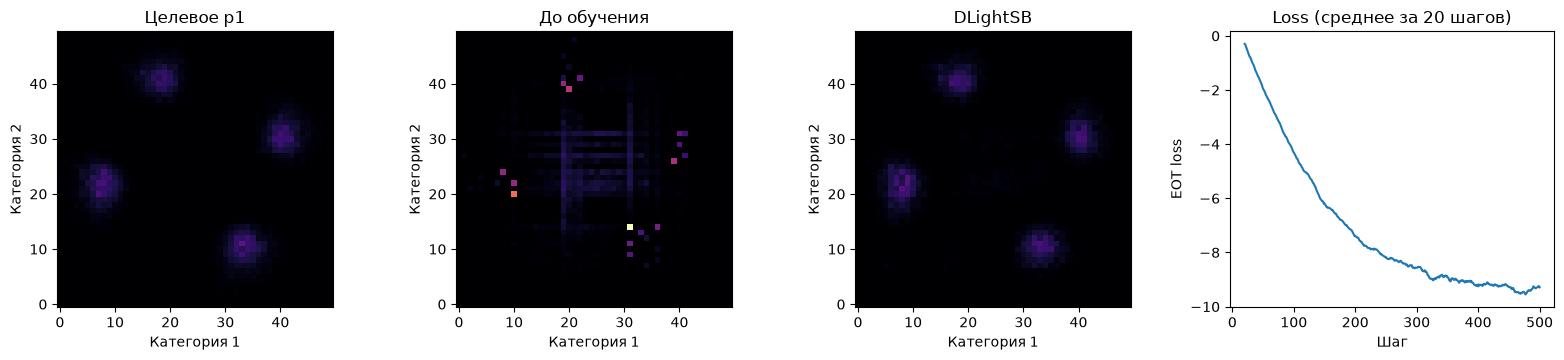

In [8]:
# DLightSB: независимое обучение и оценка на CPU, без скачивания бенчмарка.
import os
import sys
import time
from pathlib import Path
from functools import partial

os.environ["LSE_BACKEND"] = "cpu"
root = Path.cwd()
if not (root / "src" / "methods" / "dlight_sb.py").exists():
    root = root / "catsbench"
if not (root / "src" / "methods" / "dlight_sb.py").exists():
    raise RuntimeError("Запустите ноутбук из папки catsbench или её родительской папки.")
for path in (root, root / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import numpy as np
import torch
import matplotlib.pyplot as plt
from catsbench import BenchmarkHD, BenchmarkHDConfig
from catsbench.metrics import ShapeScore, TrendScore
from src.methods.dlight_sb import DLightSB

torch.set_default_device("cpu")
torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.manual_seed(42)
np.random.seed(42)
started = time.perf_counter()
N_TRAIN, N_TEST, STEPS, BATCH, K = 10_000, 10_000, 500, 256, 32

# Простой новый эталон: D=2, S=50, пять компонент; train/test генерируются отдельно.
bench = BenchmarkHD(BenchmarkHDConfig(
    dim=2, input_shape=(2,), num_categories=50, num_potentials=5,
    radius=5.0, alpha=0.02, num_timesteps=15, num_skip_steps=8,
    prior_type="gaussian", benchmark_type="gaussian",
    input_distribution="gaussian", num_val_samples=128, init_batch_size=128,
    reverse=False, tau=1.0, params_dtype="float32",
), device="cpu")

# Небольшие батчи ограничивают пиковую память при генерации.
def draw(fn, n):
    return torch.cat([fn(min(256, n - i)) for i in range(0, n, 256)])

train_x = draw(bench.sample_input, N_TRAIN)
train_y = draw(bench.sample_target, N_TRAIN)  # независимы от train_x
test_x = draw(bench.sample_input, N_TEST)
test_y = draw(bench.sample_target, N_TEST)
oracle_y = draw(bench.sample_target, N_TEST)

model = DLightSB(
    prior=bench.prior, dim=2, num_categories=50, num_potentials=K,
    num_timesteps=bench.num_timesteps, optimizer=partial(torch.optim.AdamW, lr=0.03),
    distr_init="samples", entropy_lambda=0.0,
).cpu()
model.init_weights(train_y[torch.randperm(N_TRAIN)[:K]])
dlight_initial_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
optimizer = model.configure_optimizers()["optimizer"]

@torch.no_grad()
def predict(x):
    return torch.cat([model.sample(batch) for batch in x.split(256)])

def scores(real, pred):
    result = []
    for metric_type in (ShapeScore, TrendScore):
        metric = metric_type(dim=2, num_categories=50).cpu()
        metric.update(real, pred)
        result.append(metric.compute().item())
    return result

# Условная оценка: восемь фиксированных входов, по 512 исходов каждого.
anchors = test_x[torch.linspace(0, N_TEST - 1, 8).long()]
conditions = [x[None].repeat(512, 1) for x in anchors]
conditional_truth = [torch.cat([bench.sample(b) for b in x.split(256)]) for x in conditions]

@torch.no_grad()
def conditional_trend():
    metric = TrendScore(2, 50, conditional=True)
    for x, real in zip(conditions, conditional_truth):
        metric.update(real, predict(x))
    return metric.compute().item()

before_y = predict(test_x)
before = scores(test_y, before_y) + [conditional_trend()]
losses = []
model.train()
train_started = time.perf_counter()
for step in range(STEPS):
    ix = torch.randint(N_TRAIN, (BATCH,))
    iy = torch.randint(N_TRAIN, (BATCH,))
    optimizer.zero_grad(set_to_none=True)
    loss, _ = model.loss(train_x[ix], train_y[iy])
    if not torch.isfinite(loss):
        raise RuntimeError(f"Нечисловой loss на шаге {step}.")
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
train_seconds = time.perf_counter() - train_started

model.eval()
after_y = predict(test_x)
after = scores(test_y, after_y) + [conditional_trend()]
reference = scores(test_y, oracle_y)
print(f"CPU | train: {N_TRAIN:,} + {N_TRAIN:,} | test: {N_TEST:,} | шагов: {STEPS}")
print(f"Обучение: {train_seconds:.1f} с; всего без импортов: {time.perf_counter()-started:.1f} с")
print(f"{'Метрика (больше — лучше)':<30} {'До':>8} {'После':>8}")
for name, a, b in zip(("ShapeScore", "TrendScore", "Conditional TrendScore"), before, after):
    print(f"{name:<30} {a:8.4f} {b:8.4f}")
print(f"Эталон vs эталон: Shape={reference[0]:.4f}, Trend={reference[1]:.4f}")
print("Эмпирические scores имеют шум; conditional-оценка использует только 8 входов.")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.7))
histograms = [
    np.histogram2d(y[:, 0].numpy(), y[:, 1].numpy(),
                   bins=50, range=[[-0.5, 49.5], [-0.5, 49.5]])[0] / len(y)
    for y in (test_y, before_y, after_y)
]
vmax = max(h.max() for h in histograms)
for ax, h, title in zip(axes[:3], histograms, ("Целевое p1", "До обучения", "DLightSB")):
    ax.imshow(h.T, origin="lower", extent=(-0.5, 49.5, -0.5, 49.5),
              vmin=0, vmax=vmax, cmap="magma")
    ax.set(title=title, xlabel="Категория 1", ylabel="Категория 2")
axes[3].plot(np.arange(20, STEPS + 1), np.convolve(losses, np.ones(20)/20, mode="valid"))
axes[3].set(title="Loss (среднее за 20 шагов)", xlabel="Шаг", ylabel="EOT loss")
plt.tight_layout()
plt.show()


CPU | train: 10,000 + 10,000 | test: 10,000
MM-итераций: 94; обучение: 4.5 с; всего: 5.3 с
Метрика (больше — лучше)        До MM   После MM    AdamW
ShapeScore                     0.5590     0.9582   0.9307
TrendScore                     0.1214     0.8469   0.8094
Conditional TrendScore         0.0176     0.7803   0.6653
Полный train loss: 0.254147 → -9.636478
Максимальное увеличение loss за шаг: 0.00e+00
Эталон vs эталон: Shape=0.9699, Trend=0.8708
Один MM-шаг обрабатывает весь train, шаг AdamW — батч. Conditional: 8 входов.


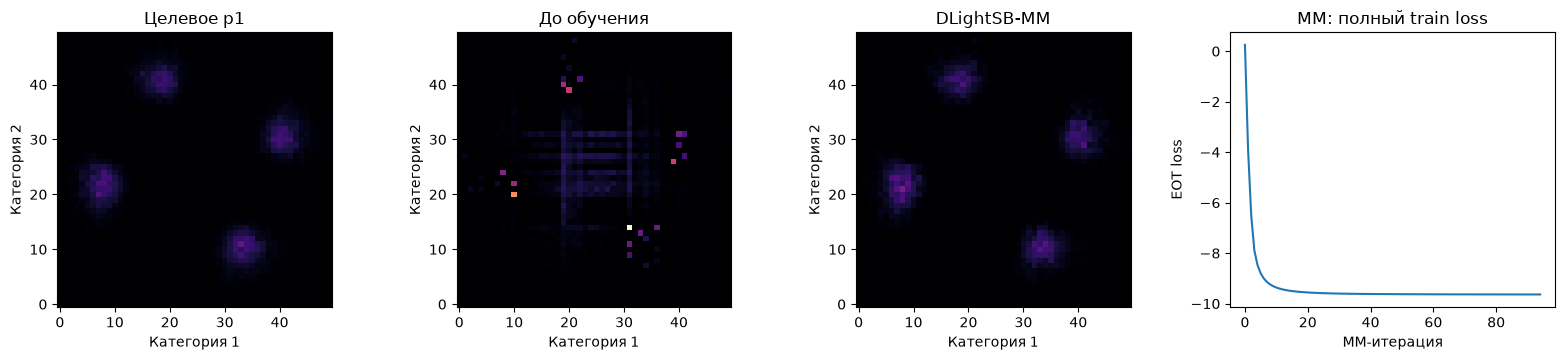

In [9]:
# DLightSB-MM: те же данные и начальные параметры, что в предыдущей ячейке.
from src.methods.dlight_sb_mm import DLightSBMM

required = ("dlight_initial_state", "train_x", "train_y", "test_x", "test_y",
            "conditions", "conditional_truth", "model", "after", "reference")
if any(name not in globals() for name in required):
    raise RuntimeError("Сначала выполните предыдущую ячейку DLightSB.")

mm_started = time.perf_counter()
mm_model = DLightSBMM.from_model(model, state_dict=dlight_initial_state)

@torch.no_grad()
def mm_predict(x):
    return torch.cat([mm_model.sample(batch) for batch in x.split(256)])

@torch.no_grad()
def mm_conditional_trend():
    metric = TrendScore(2, 50, conditional=True).cpu()
    for x, real in zip(conditions, conditional_truth):
        metric.update(real, mm_predict(x))
    return metric.compute().item()

torch.manual_seed(123)
mm_before_y = mm_predict(test_x)
mm_before = scores(test_y, mm_before_y) + [mm_conditional_trend()]
mm_train_started = time.perf_counter()
mm_history = mm_model.fit_mm(train_x, train_y, max_iter=200, tol=1e-5)
mm_train_seconds = time.perf_counter() - mm_train_started

torch.manual_seed(123)
mm_after_y = mm_predict(test_x)
mm_after = scores(test_y, mm_after_y) + [mm_conditional_trend()]
print(f"CPU | train: {len(train_x):,} + {len(train_y):,} | test: {len(test_x):,}")
print(f"MM-итераций: {len(mm_history)-1}; обучение: {mm_train_seconds:.1f} с; "
      f"всего: {time.perf_counter()-mm_started:.1f} с")
print(f"{'Метрика (больше — лучше)':<28} {'До MM':>8} {'После MM':>10} {'AdamW':>8}")
for name, a, b, adam in zip(
    ("ShapeScore", "TrendScore", "Conditional TrendScore"), mm_before, mm_after, after
):
    print(f"{name:<28} {a:8.4f} {b:10.4f} {adam:8.4f}")
print(f"Полный train loss: {mm_history[0]:.6f} → {mm_history[-1]:.6f}")
print(f"Максимальное увеличение loss за шаг: {max(0.0, max(np.diff(mm_history))):.2e}")
print(f"Эталон vs эталон: Shape={reference[0]:.4f}, Trend={reference[1]:.4f}")
print("Один MM-шаг обрабатывает весь train, шаг AdamW — батч. Conditional: 8 входов.")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.7))
mm_histograms = [
    np.histogram2d(y[:, 0].numpy(), y[:, 1].numpy(),
                   bins=50, range=[[-0.5, 49.5], [-0.5, 49.5]])[0] / len(y)
    for y in (test_y, mm_before_y, mm_after_y)
]
vmax = max(h.max() for h in mm_histograms)
for ax, h, title in zip(axes[:3], mm_histograms, ("Целевое p1", "До обучения", "DLightSB-MM")):
    ax.imshow(h.T, origin="lower", extent=(-0.5, 49.5, -0.5, 49.5),
              vmin=0, vmax=vmax, cmap="magma")
    ax.set(title=title, xlabel="Категория 1", ylabel="Категория 2")
axes[3].plot(mm_history)
axes[3].set(title="MM: полный train loss", xlabel="MM-итерация", ylabel="EOT loss")
plt.tight_layout()
plt.show()
